In [1]:
import pandas as pd
import json
from pathlib import Path
from elasticsearch import Elasticsearch, helpers
from pprint import pprint
import matplotlib.pyplot as plt
import seaborn as sns
import re
from IPython.display import Markdown, display
import subprocess
import shutil

In [2]:
BASE_DIR = Path.cwd()                        
DATA_DIR = BASE_DIR 
CSV_PATH = DATA_DIR / "documents.csv"
JSONL_PATH = DATA_DIR / "documents.jsonl"
QUERIES_PATH = DATA_DIR / "queries.csv"
QRELS_PATH = DATA_DIR / "qrels.csv"

In [3]:
# Load CSV File
try:
    df = pd.read_csv(CSV_PATH, encoding="utf-8")
except FileNotFoundError:
    raise SystemExit(f"File not found: {CSV_PATH}")
except Exception as e:
    raise SystemExit(f"Error reading CSV: {e}")

In [4]:
# Display Columns and Document Count
print(f"CSV loaded successfully → {len(df)} documents found")
print(f"Columns detected: {list(df.columns)}")

CSV loaded successfully → 18316 documents found
Columns detected: ['ID', 'Text']


In [5]:
# Validate Required Columns
required_cols = {"ID", "Text"}
missing = required_cols - set(df.columns)
if missing:
    raise SystemExit(f"Missing expected columns: {missing}")

In [6]:
def preprocess(s):
    if not isinstance(s, str):
        return ""
    s = s.lower()
    s = re.sub(r"http\S+|www\S+", "", s)
    s = re.sub(r"[^a-zA-Z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s)
    return s.strip()


df = df.dropna(subset=["Text"])
df["Text"] = df["Text"].astype(str).map(preprocess)

In [7]:
# Convert to JSONL
records_written = 0
with open(JSONL_PATH, "w", encoding="utf-8") as f:
    for _, row in df.iterrows():
        record = {
            "id": row["ID"],     
            "text": row["Text"]
        }
        json_line = json.dumps(record, ensure_ascii=False)
        f.write(json_line + "\n")
        records_written += 1

print(f"Converted {records_written} rows → JSONL format")
print(f"Output saved at: {JSONL_PATH.resolve()}")

Converted 18316 rows → JSONL format
Output saved at: C:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\documents.jsonl


In [8]:
class Search:
    def __init__(self):
        self.es = Elasticsearch("http://127.0.0.1:9200")
        client_info = self.es.info()
        print('Connected to Elasticsearch!')
        pprint(client_info.body)

    #Return instance
    def get_es(self):
        return self.es

    #Creates empty index with the parameters we feed
    def create_index(self):
        index_settings = {
            "settings": {
                "analysis": {
                    "analyzer": {
                        "my_custom_analyzer": {
                            "type": "custom",
                            "tokenizer": "standard",
                            "filter": [
                                "lowercase",
                                "stop",
                                "porter_stem"
                            ]
                        }
                    }
                },
                "similarity": {
                    "bm25_tuned": {
                        "type": "BM25",
                        "k1": 1.4,
                        "b": 0.55
                    }
                }
            },
            "mappings": {
                "properties": {
                    "text": {
                        "type": "text",
                        "analyzer": "my_custom_analyzer",
                        "similarity": "bm25_tuned"
                    }
                }
            }
        }

        # Delete existing index
        if self.es.indices.exists(index=self.index_name):
            self.es.indices.delete(index=self.index_name)

        # Create new index
        self.es.indices.create(index=self.index_name, body=index_settings)
        print(f"Index '{self.index_name}' created successfully with BM25 tuning!")



    #Insert single document
    def insert_document(self, document):
        return self.es.index(index='ir2025', document=document)

    #Insert multiple indexes
    def insert_documents(self, documents):
        operations = []
        for document in documents:
            operations.append({'index': {'_index': 'ir2025'}})
            operations.append(document)

        result = self.es.bulk(operations=operations)
        print("Insertion finished.")
        print(result)

    #Deletes index
    def delete_index(self, index_name="ir2025"):
        if self.es.indices.exists(index=index_name):
            self.es.indices.delete(index=index_name)
            print(f"Index '{index_name}' deleted successfully.")
        else:
            print(f"Index '{index_name}' does not exist.")

    #Check if index exists
    def exists(self, index_name="ir2025"):
        try:
            return self.es.indices.exists(index=index_name)
        except Exception as e:
            print(f"Error checking if index exists: {e}")
            return False

    #Helper function for bulk indexing
    def generate_actions(self, jsonl_path, index_name):
        with open(jsonl_path, encoding="utf-8") as f:
            for i, line in enumerate(f):
                yield {
                    "_index": index_name,
                    "_id": i,
                    "_source": json.loads(line)
                }

    #Bulk index docs
    def index_documents(self, jsonl_path, index_name):
        actions = self.generate_actions(jsonl_path, index_name)
        success, _ = helpers.bulk(self.get_es(), actions)
        print(f"Successfully indexed {success} documents into '{index_name}'")

    #Runs query
    def search_query(self, query_text, k=10, index_name="ir2025"):
        try:
            resp = self.es.search(
                index=index_name,
                query={"match": {"text": {"query": query_text}}},
                size=k
            )
            return resp["hits"]["hits"]
        except Exception as e:
            print(f"Error executing search query: {e}")
            return []


In [9]:
class Evaluation:
    def __init__(self, data_dir: Path):
        self.DATA_DIR = data_dir
        self.RESULT_KS = [20, 30, 50]
        self.OUT_SUM = self.DATA_DIR / "trec_eval_summary.txt"

        # locate trec_eval.exe
        self.TRECEVAL_BIN = self.find_trec_eval()
        if self.TRECEVAL_BIN is None:
            raise SystemExit(
                "trec_eval binary not found.\n"
                "Put trec_eval.exe inside the IR2025/ folder or update DATA_DIR."
            )

        # qrels path
        self.qrels_fixed = self.DATA_DIR / "qrels.txt"
        if not self.qrels_fixed.exists():
            raise SystemExit(f"qrels file not found: {self.qrels_fixed}")

    # -----------------------------------------------------
    # locate trec_eval.exe in common places
    # -----------------------------------------------------
    def find_trec_eval(self):
        CANDIDATES = [
            self.DATA_DIR / "trec_eval" / "trec_eval.exe",
            self.DATA_DIR / "trec_eval" / "trec_eval",
            self.DATA_DIR / "trec_eval.exe",
            self.DATA_DIR / "trec_eval",
        ]

        for p in CANDIDATES:
            if p.exists():
                return p

        # PATH lookup
        p = shutil.which("trec_eval") or shutil.which("trec_eval.exe")
        if p:
            return Path(p)

        # recursive search
        for p in self.DATA_DIR.rglob("trec_eval*"):
            if p.is_file():
                return p

        return None

    # -----------------------------------------------------
    # run trec_eval -m all_trec and return stdout
    # -----------------------------------------------------
    def run_all_trec(self, qrels_path, results_path, timeout=120):
        cmd = [
            str(self.TRECEVAL_BIN),
            str(qrels_path),
            str(results_path),
            "-m", "all_trec"
        ]

        print("Running:", " ".join(cmd))
        proc = subprocess.run(cmd, capture_output=True, text=True, timeout=timeout)

        print("RC:", proc.returncode)
        if proc.stdout:
            print("--- trec_eval stdout (truncated) ---")
            print("\n".join(proc.stdout.splitlines()[:20]))

        if proc.stderr:
            print("--- trec_eval stderr ---")
            print(proc.stderr)

        if proc.returncode != 0:
            raise SystemExit("trec_eval failed. See stderr above.")

        return proc.stdout

    # -----------------------------------------------------
    # parse output of -m all_trec
    # -----------------------------------------------------
    def parse_all_trec_stdout(self, stdout_text):
        res = {}
        for ln in stdout_text.splitlines():
            parts = re.split(r"\s+", ln.strip())
            if len(parts) < 3:
                continue

            metric_tok = parts[0]
            target_tok = parts[1]
            val_tok = parts[-1]

            if target_tok.lower() != "all":
                continue

            # MAP
            if metric_tok.lower().startswith("map"):
                try:
                    res["MAP"] = float(val_tok)
                except:
                    res["MAP"] = None
                continue

            # P@k
            m = re.match(r"P[._]?(\d+)", metric_tok, flags=re.IGNORECASE)
            if m:
                k = int(m.group(1))
                try:
                    res[f"P@{k}"] = float(val_tok)
                except:
                    res[f"P@{k}"] = None
        return res

    # -----------------------------------------------------
    # Main evaluation
    # -----------------------------------------------------
    def evaluate_trec(self):
        summary_rows = []

        for k in self.RESULT_KS:
            results_file = self.DATA_DIR / f"results_{k}.txt"
            if not results_file.exists():
                print(f"Missing results file: {results_file} — skipping.")
                continue

            print(f"\n=== Running trec_eval for k={k} ===")
            stdout = self.run_all_trec(self.qrels_fixed, results_file)
            parsed = self.parse_all_trec_stdout(stdout)

            summary_rows.append({
                "retrieval_k": k,
                "P@5": parsed.get("P@5"),
                "P@10": parsed.get("P@10"),
                "P@15": parsed.get("P@15"),
                "P@20": parsed.get("P@20"),
                "MAP": parsed.get("MAP")
            })

        df = pd.DataFrame(summary_rows).sort_values("retrieval_k").reset_index(drop=True)

        print("\n--- TREC EVALUATION SUMMARY ---")
        print(df.to_string(index=False))

        # write trec-style summary file
        with open(self.OUT_SUM, "w", encoding="utf-8") as f:
            for _, row in df.iterrows():
                k = int(row["retrieval_k"])
                f.write(f"# summary for results_{k}.txt\n")
                for kk in [5, 10, 15, 20]:
                    val = row.get(f"P@{kk}")
                    f.write(f"P_{kk}\tall\t{val:.4f}\n" if val else f"P_{kk}\tall\tNaN\n")
                mapv = row.get("MAP")
                f.write(f"map\tall\t{mapv:.4f}\n\n" if mapv else "map\tall\tNaN\n\n")

        print(f"\nWrote trec-style summary to: {self.OUT_SUM}")
        return df


In [10]:
#Initiate search class and index name
search=Search()
INDEX_NAME = "ir2025" 

Connected to Elasticsearch!
{'cluster_name': 'elasticsearch',
 'cluster_uuid': 'NfFciNgwSE648-kMzsJiVg',
 'name': 'SWKRATISLAPTOP',
 'tagline': 'You Know, for Search',
 'version': {'build_date': '2025-09-16T22:05:19.073893347Z',
             'build_flavor': 'default',
             'build_hash': '0b7fe68d2e369469ff9e9f344ab6df64ab9c5293',
             'build_snapshot': False,
             'build_type': 'zip',
             'lucene_version': '10.2.2',
             'minimum_index_compatibility_version': '8.0.0',
             'minimum_wire_compatibility_version': '8.19.0',
             'number': '9.1.4'}}


In [11]:
#Delete index if exists
if search.exists(INDEX_NAME):
    search.delete_index(index_name=INDEX_NAME)
    
#Create new empty index
search.create_index()

#Index docs
search.index_documents(JSONL_PATH,INDEX_NAME)

Index 'ir2025' deleted successfully.


AttributeError: 'Search' object has no attribute 'index_name'

In [12]:
evaluator = Evaluation(DATA_DIR)
df_trec = evaluator.evaluate_trec()
df_trec


=== Running trec_eval for k=20 ===
Running: c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\trec_eval\trec_eval.exe c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\qrels.txt c:\Users\swkra\OneDrive - aueb.gr\Uni\7th-semester\SystemsRetr\ergasia\IR2025\results_20.txt -m all_trec
RC: 0
--- trec_eval stdout (truncated) ---
runid                 	all	BM25
num_q                 	all	10
num_ret               	all	200
num_rel               	all	152
num_rel_ret           	all	70
map                   	all	0.3163
gm_map                	all	0.2769
Rprec                 	all	0.4140
bpref                 	all	0.4663
recip_rank            	all	0.8833
iprec_at_recall_0.00  	all	0.9317
iprec_at_recall_0.10  	all	0.7834
iprec_at_recall_0.20  	all	0.6440
iprec_at_recall_0.30  	all	0.5009
iprec_at_recall_0.40  	all	0.3764
iprec_at_recall_0.50  	all	0.2667
iprec_at_recall_0.60  	all	0.1596
iprec_at_recall_0.70  	all	0.0769
iprec_at_recall_0.80 

,retrieval_k,P@5,P@10,P@15,P@20,MAP
0,20,0.6,0.48,0.40,0.350,0.3163
1,30,0.6,0.48,0.40,0.350,0.3313
2,50,0.8,0.70,0.58,0.515,0.6355


In [13]:
# Visualize Results
def visualize_metrics(df):
    import seaborn as sns
    import matplotlib.pyplot as plt

    # Correct id_var name
    df = df.rename(columns={"retrieval_k": "Retrieval_k"})

    # Metrics to visualize
    metrics_to_plot = ["P@5", "P@10", "P@15", "P@20", "MAP"]

    # Melt for seaborn compatibility
    df_melted = df.melt(
        id_vars="Retrieval_k",
        value_vars=metrics_to_plot,
        var_name="Metric",
        value_name="Score"
    )

    sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)

    # Create side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    plt.subplots_adjust(wspace=0.15)

    # ---------------------------------------------
    # Left plot: Line Plot for All Metrics
    # ---------------------------------------------
    sns.lineplot(
        data=df_melted,
        x="Retrieval_k",
        y="Score",
        hue="Metric",
        marker='o',
        dashes=False,
        palette="deep",
        ax=ax1
    )

    ax1.set_title("Metric Trends Across Retrieval Depth ($k_{max}$)", fontsize=14, weight="bold")
    ax1.set_xlabel("$k_{max}$", fontsize=12)
    ax1.set_ylabel("Score", fontsize=12)
    ax1.set_ylim(df_melted["Score"].min() * 0.9, 1.05)
    ax1.legend(title="Metric", loc="upper right")
    ax1.grid(axis='y')

    # Annotate MAP values
    map_data = df_melted[df_melted["Metric"] == "MAP"]
    for x, y in zip(map_data["Retrieval_k"], map_data["Score"]):
        ax1.text(x + 0.1, y, f'{y:.4f}', color='red', ha='left', va='center', fontsize=10)

    # ---------------------------------------------
    # Right plot: Bar Plot for MAP Only
    # ---------------------------------------------
    map_only_data = df_melted[df_melted["Metric"] == "MAP"]

    sns.barplot(
        data=map_only_data,
        x="Retrieval_k",
        y="Score",
        palette=sns.color_palette("Reds_d", n_colors=len(map_only_data)),
        ax=ax2
    )

    ax2.set_title("Mean Average Precision (MAP) by $k_{max}$", fontsize=14, weight="bold")
    ax2.set_xlabel("$k_{max}$", fontsize=12)
    ax2.set_ylabel("", fontsize=12)
    ax2.set_ylim(df_melted["Score"].min() * 0.9, 1.05)

    # Bar labels
    for container in ax2.containers:
        ax2.bar_label(container, fmt="%.4f", label_type="center", fontsize=12, color='white', weight='bold')

    plt.tight_layout()
    plt.show()


C:\Users\swkra\AppData\Local\Temp\ipykernel_26064\1248865664.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


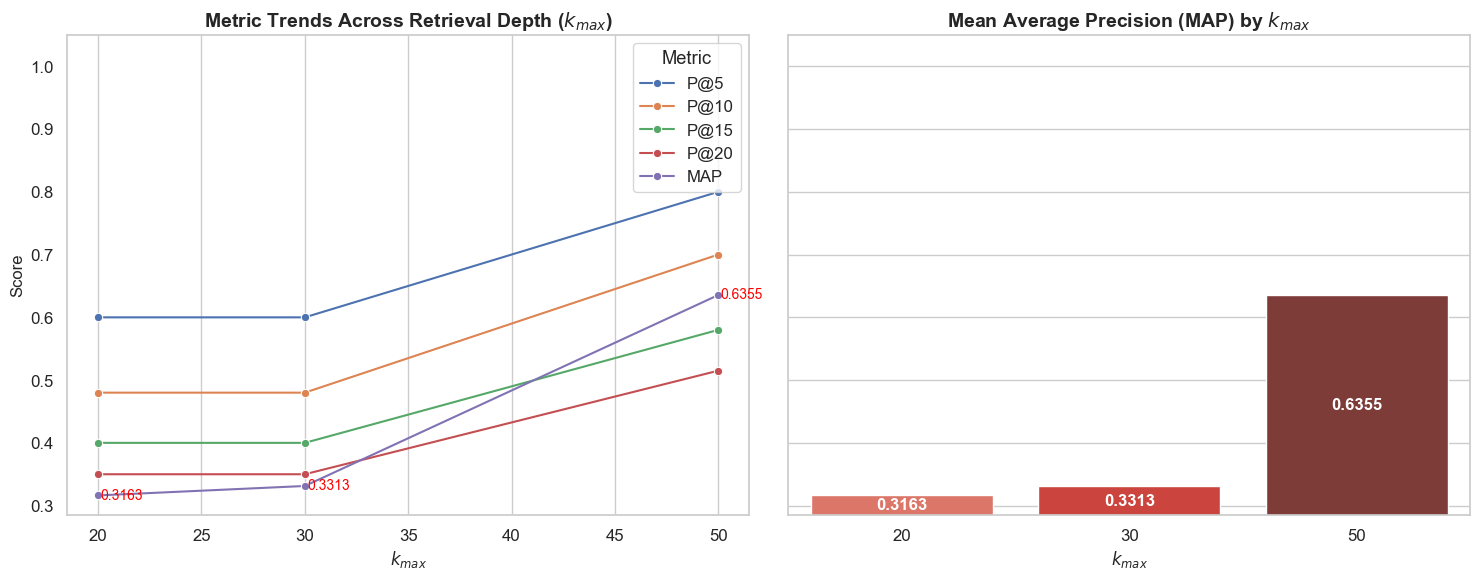

In [20]:
visualize_metrics(df_trec)